# 12 · Resource coupling — gating notebook (Tier-A repaired)

**The substantive question.** Does the trust-centric model produce the
path-dependent paradigm dynamics that the paper's Claim 1 (§4.5)
claims, or is the apparent loop a trivial cost-on-policy effect?

**The structure of the gate.** Four runs over $S$ seeds each on a
two-community SBM under the reversal schedule $\theta^*: 0 \to 1 \to 0$:

| Run | Description | Role |
|---|---|---|
| **A** | Low $R_{\rm in}$, asymmetric init | Anchor: entrenched, low-resource regime |
| **B** | High $R_{\rm in}$, asymmetric init | Anchor: enabled paradigm-shift regime |
| **C** | High $R_{\rm in}$, **`fisher_cost_steepness = 0`** | §4.5 falsifier control: cost r-independent ⇒ loop should vanish |
| **D** | High $R_{\rm in}$, **`learning = False`** | Trust-freeze ablation: tests whether $\Gamma$-drift is load-bearing |

The new gate's pass criteria (replacing the prior single-seed pass):

1. **Monotonicity:** B shifts faster than A on community 0 in ≥8/10 seeds.
2. **Claim 1 (falsifier-isolated):** loop_area(B) > 3 · loop_area(C) in
   ≥8/10 seeds. If C ≈ B, the paper's *trust-mediated* mechanism is not
   what drives B's loop; the loop is a trivial consequence of the cost
   barrier.
3. **Trust drives drift (Krakauer):** $\|\Delta\Gamma\|_F$ in B > D in
   the median. If D ≈ B, trust is decorative.
4. **Per-community asymmetry (social-science):** communities 0 and 1
   produce visibly different $\bar\mu_k(t)$ trajectories under the
   asymmetric init. If they don't, the SBM structure is doing no work.

If any of (2), (3), (4) fails, the gate fails and the model needs Tier-B
repair or §5 needs rewriting before Phase 3 axis sweeps. **The failure
modes are part of the design** — see [[feedback_honest_structural_findings]].


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from dataclasses import replace

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import equinox as eqx
import seaborn as sns

from src import (
    History, ModelConfig, NetworkConfig, PolicyConfig, ResourceConfig,
    TrustConfig, InferenceConfig, UtilityConfig, WorldConfig,
)
from src.network import build_adjacency
from src.population import Population
from src import resource as resmod
from src import observables as obs

sns.set_theme(context='notebook', style='whitegrid')
print('imports ok')


imports ok


## §1 · Setup

Two communities of 20 agents each on an SBM (intra=0.4, inter=0.02).
Asymmetric per-community init (a Tier-A addition vs. the prior symmetric
gate):

- **Community 0** (mainstream / Newtonian): $\mu_0 = 0.0$, $\tau_0 = 1.0$
- **Community 1** (vanguard / half-way): $\mu_0 = 0.5$, $\tau_0 = 2.0$

The reversal schedule:

| Window | $\theta^*$ | Phase |
|---|---|---|
| $t \in [0, 60]$ | 0 | Newtonian baseline |
| $t \in [60, 200]$ | 1 | Relativistic regime |
| $t \in [200, 300]$ | 0 | Reversal back to Newtonian |


In [2]:
N = 40
N_PER = 20
T_TOTAL = 300
T_SHIFT = 60
T_REVERSE = 200

N_SEEDS = 10   # multi-seed strip; gate criteria use medians + 8/10-seed votes

membership = np.array([0] * N_PER + [1] * N_PER)
community_0_mask = membership == 0
community_1_mask = membership == 1

# Asymmetric per-community init for the gating runs.
MU_0_C0, TAU_0_C0 = 0.0, 1.0
MU_0_C1, TAU_0_C1 = 0.5, 2.0


def build_sbm(seed: int) -> jnp.ndarray:
    A = build_adjacency(
        n_agents=N, mean_degree=4, rewiring_p=0.0, seed=seed,
        kind='planted_sbm', society_membership=membership,
        intra_prob=0.4, inter_prob=0.02,
    )
    return jnp.asarray(A)


## §2 · Schedule preview

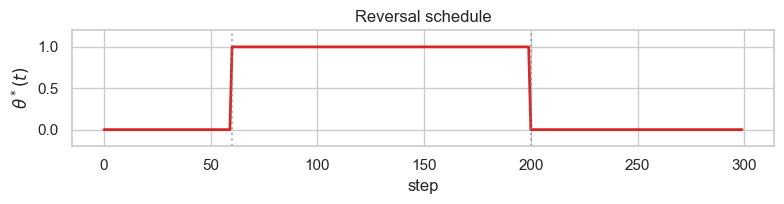

In [3]:
theta_preview = np.zeros(T_TOTAL)
for t in range(T_TOTAL):
    if t < T_SHIFT:
        theta_preview[t] = 0.0
    elif t < T_REVERSE:
        theta_preview[t] = 1.0
    else:
        theta_preview[t] = 0.0

fig, ax = plt.subplots(figsize=(8, 2.2))
ax.plot(theta_preview, lw=2, color='#d62728')
ax.axvline(T_SHIFT, color='gray', ls=':', alpha=0.6)
ax.axvline(T_REVERSE, color='gray', ls=':', alpha=0.6)
ax.set(xlabel='step', ylabel=r'$\theta^*(t)$', ylim=(-0.2, 1.2),
       title='Reversal schedule')
plt.tight_layout()
plt.show()


## §3 · Configs and run-helpers

Four configs share most parameters; they differ only in:

- **Run A:** `R_in = 0.5`, `fisher_cost_steepness = 1.0`, `learning = True`
- **Run B:** `R_in = 10.0`, `fisher_cost_steepness = 1.0`, `learning = True`
- **Run C:** `R_in = 10.0`, **`fisher_cost_steepness = 0.0`** (Claim-1 falsifier control: cost is r-independent and zero)
- **Run D:** `R_in = 10.0`, **`learning = False`** (trust-freeze ablation)

Calibration notes (load-bearing — see
[[project_substrate_phase1_complete]] and
[[project_gating_notebook12]]):

- `posterior_rho = 1.0` (no forgetting) is safe with `lambda_mc = 0`.
- `c0 = 0.01`, `tau_0_c0 = 1.0` balance against the per-agent inflow
  share. Plan's c0=0.5/tau_0=10 numbers freeze the population at any
  reasonable R_in.


In [4]:
def make_cfg(R_in: float, c0: float = 0.01, lam: float = 0.0,
             learning: bool = True, fisher_steepness: float = 1.0,
             seed: int = 7) -> ModelConfig:
    return ModelConfig(
        n_agents=N, seed=seed,
        mu_0=MU_0_C0, tau_0=TAU_0_C0,    # community 0 init (overridden for c1 below)
        world=WorldConfig(
            schedule='reversal',
            schedule_t_shift=T_SHIFT,
            schedule_t_reverse=T_REVERSE,
            theta_star_pre=0.0, theta_star_post=1.0,
        ),
        policy=PolicyConfig(
            objective='resource_gain',
            x_grid=(0.3, 1.0, 2.0, 3.0),
            beta_exp=2.0,
        ),
        inference=InferenceConfig(posterior_rho=1.0),
        trust=TrustConfig(rho=0.99, prior_n0=1.0, prior_eps0=1.0,
                          learning=learning),
        network=NetworkConfig(kind='watts_strogatz', mean_degree=4),  # placeholder; SBM is patched in
        resource=ResourceConfig(
            R_in=R_in, alpha_flow=0.15, delta_decay=0.02,
            r0=3.0, c0=c0, r_min=0.0,
            fisher_cost_steepness=fisher_steepness, barrier_eps=1e-3,
        ),
        utility=UtilityConfig(lambda_mc=lam),
    )


def build_with_sbm_asymmetric(cfg: ModelConfig, A_jax: jnp.ndarray,
                              homogeneous: bool = False) -> Population:
    """Build the population, swap in the SBM adjacency, and apply the
    per-community μ_0/τ_0 init.

    homogeneous=True forces all agents to (MU_0_C0, TAU_0_C0); used to
    flag the §4.5 falsifier control if we ever want to run it with
    homogeneous init AND fisher_steepness=0 (the strict two-pronged
    condition).
    """
    pop = Population.init(cfg, jax.random.PRNGKey(cfg.seed))
    A_self = A_jax + jnp.eye(N, dtype=A_jax.dtype)
    n0 = cfg.trust.prior_n0
    beta0 = cfg.trust.prior_n0 * cfg.trust.prior_eps0
    alpha = n0 * A_self
    beta_ = beta0 * A_self
    gamma_raw = (alpha / (beta_ + 1e-12)) * A_self
    row_sum = gamma_raw.sum(axis=1, keepdims=True) + 1e-12
    gamma = (gamma_raw / row_sum) * A_self

    # Per-community μ, τ.
    if homogeneous:
        mu = jnp.full((N,), MU_0_C0)
        tau = jnp.full((N,), TAU_0_C0)
    else:
        mu = jnp.where(jnp.asarray(community_0_mask), MU_0_C0, MU_0_C1)
        tau = jnp.where(jnp.asarray(community_0_mask), TAU_0_C0, TAU_0_C1)

    return eqx.tree_at(
        lambda p: (p.A_adj, p.A_self_adj, p.alpha, p.beta, p.gamma, p.mu, p.tau),
        pop, (A_jax, A_self, alpha, beta_, gamma, mu, tau),
    )


def run_one(cfg: ModelConfig, A_jax: jnp.ndarray, *,
             homogeneous: bool = False) -> dict:
    """Run one seed of one config. Returns a diagnostics dict.

    Snapshots include μ, τ, γ, r at every step; the .Frob-norm trust
    drift series is computed in-loop to avoid stacking the whole γ
    series (N×N×T ≈ 4.8M floats per run otherwise).
    """
    pop = build_with_sbm_asymmetric(cfg, A_jax, homogeneous=homogeneous)

    gamma0 = np.asarray(pop.gamma)  # for ‖ΔΓ‖_F
    eta0 = obs.aggregate_trust(gamma0)

    mu_c0_t = np.zeros(T_TOTAL)
    mu_c1_t = np.zeros(T_TOTAL)
    r_c0_gini_t = np.zeros(T_TOTAL)
    r_c1_gini_t = np.zeros(T_TOTAL)
    rw_div_c0_t = np.zeros(T_TOTAL)
    rw_div_c1_t = np.zeros(T_TOTAL)
    gamma_drift_t = np.zeros(T_TOTAL)
    eta_kl_t = np.zeros(T_TOTAL)
    theta_trace = np.zeros(T_TOTAL)
    gini_global_t = np.zeros(T_TOTAL)

    def gini_arr(v):
        v = np.asarray(v)
        if v.sum() <= 0:
            return 0.0
        diff = np.abs(v[:, None] - v[None, :]).sum()
        return diff / (2.0 * len(v) * v.sum() + 1e-12)

    for t in range(T_TOTAL):
        pop, out = pop.step(t)
        theta_trace[t] = out['theta_star']

        mu_np = np.asarray(pop.mu)
        r_np = np.asarray(pop.r)
        gamma_np = np.asarray(pop.gamma)

        mu_c0_t[t] = mu_np[community_0_mask].mean()
        mu_c1_t[t] = mu_np[community_1_mask].mean()
        r_c0 = r_np[community_0_mask]
        r_c1 = r_np[community_1_mask]
        r_c0_gini_t[t] = gini_arr(np.clip(r_c0, 0, None))
        r_c1_gini_t[t] = gini_arr(np.clip(r_c1, 0, None))
        gini_global_t[t] = gini_arr(np.clip(r_np, 0, None))

        # Resource-weighted divergence from θ*(t).
        theta_t = out['theta_star']
        r_pos = np.clip(r_np, 0, None)
        rs = r_pos.sum() + 1e-12
        share = r_pos / rs
        rw_div_c0_t[t] = (share[community_0_mask] *
                          np.abs(mu_np[community_0_mask] - theta_t)).sum()
        rw_div_c1_t[t] = (share[community_1_mask] *
                          np.abs(mu_np[community_1_mask] - theta_t)).sum()

        gamma_drift_t[t] = np.linalg.norm(gamma_np - gamma0, ord='fro')
        eta_t = obs.aggregate_trust(gamma_np)
        # KL(eta_t || eta_0); both probability vectors.
        p, q = eta_t, eta0
        mask = (p > 1e-12)
        eta_kl_t[t] = (p[mask] * np.log(p[mask] / (q[mask] + 1e-12))).sum()

    # Loop areas (per community).
    def loop_area(mu_seq, theta_seq):
        n = len(mu_seq)
        area = 0.0
        for i in range(n):
            j = (i + 1) % n
            area += theta_seq[i] * mu_seq[j] - theta_seq[j] * mu_seq[i]
        return abs(area) / 2.0

    # time_to_shift: first t >= T_SHIFT with μ̄_c0 ≥ 0.5.
    after_shift_mu = mu_c0_t[T_SHIFT:]
    crossed = np.where(after_shift_mu >= 0.5)[0]
    tts_c0 = int(crossed[0]) + T_SHIFT if len(crossed) else None

    return dict(
        theta_trace=theta_trace,
        mu_c0_t=mu_c0_t, mu_c1_t=mu_c1_t,
        r_c0_gini_t=r_c0_gini_t, r_c1_gini_t=r_c1_gini_t,
        gini_global_t=gini_global_t,
        rw_div_c0_t=rw_div_c0_t, rw_div_c1_t=rw_div_c1_t,
        gamma_drift_t=gamma_drift_t, eta_kl_t=eta_kl_t,
        loop_area_c0=loop_area(mu_c0_t, theta_trace),
        loop_area_c1=loop_area(mu_c1_t, theta_trace),
        time_to_shift_c0=tts_c0,
        r_final=np.asarray(pop.r),
        gamma_final=np.asarray(pop.gamma),
        gamma_init=gamma0,
    )


## §4 · Run the multi-seed strip

For each of Runs A, B, C, D, run $N_{\rm SEEDS}$ seeds. JIT cache stays
warm across seeds within a run; total wall-clock ≈ 6–10 minutes on CPU.


In [5]:
RUN_CONFIGS = {
    'A': dict(R_in=0.5,  c0=0.01, fisher_steepness=1.0, learning=True),
    'B': dict(R_in=10.0, c0=0.01, fisher_steepness=1.0, learning=True),
    'C': dict(R_in=10.0, c0=0.01, fisher_steepness=0.0, learning=True),   # §4.5 falsifier
    'D': dict(R_in=10.0, c0=0.01, fisher_steepness=1.0, learning=False),  # trust-freeze
}

results = {k: [] for k in RUN_CONFIGS}

for run_id, cfg_kwargs in RUN_CONFIGS.items():
    print(f'Running {run_id}: {cfg_kwargs}')
    for s in range(N_SEEDS):
        cfg = make_cfg(seed=s, **cfg_kwargs)
        A_jax = build_sbm(seed=s)
        res = run_one(cfg, A_jax)
        results[run_id].append(res)
    print(f'  done {run_id} ({N_SEEDS} seeds)')

print('all runs complete')


Running A: {'R_in': 0.5, 'c0': 0.01, 'fisher_steepness': 1.0, 'learning': True}


  done A (10 seeds)
Running B: {'R_in': 10.0, 'c0': 0.01, 'fisher_steepness': 1.0, 'learning': True}


  done B (10 seeds)
Running C: {'R_in': 10.0, 'c0': 0.01, 'fisher_steepness': 0.0, 'learning': True}


  done C (10 seeds)
Running D: {'R_in': 10.0, 'c0': 0.01, 'fisher_steepness': 1.0, 'learning': False}


  done D (10 seeds)
all runs complete


## §5 · Headline figure — four rows

1. Per-community $\bar\mu_k(t)$ for Runs A and B (one seed shown; seed=0).
2. Per-community resource Gini (positive part of $r$) for Runs A vs B.
3. Trust drift $\|\Gamma(t) - \Gamma(0)\|_F$ for all four runs.
4. Per-community resource-weighted divergence from $\theta^*(t)$.

Run-D shows the trust-frozen baseline; Run-C shows the falsifier control.
A model in which $\Gamma$ is load-bearing should show row 3 separating B
from D substantially.


C:\Users\Jonas\AppData\Local\Temp\ipykernel_2872\2495646264.py:58: UserWarning: Glyph 8314 (\N{SUPERSCRIPT PLUS SIGN}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\Jonas\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8314 (\N{SUPERSCRIPT PLUS SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


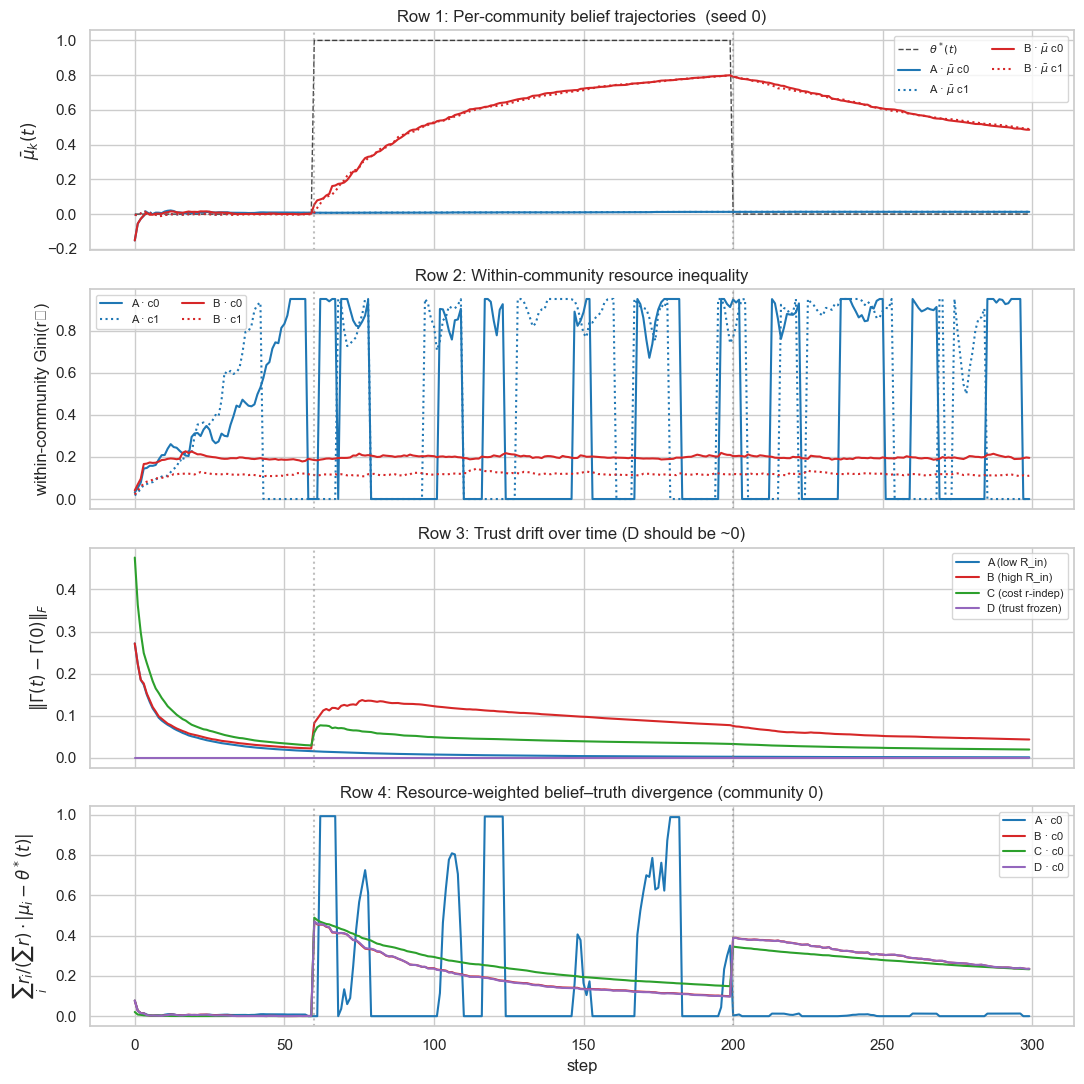

In [6]:
# Use seed=0 for the headline plot; the multi-seed distribution panel is below.
sA = results['A'][0]
sB = results['B'][0]
sC = results['C'][0]
sD = results['D'][0]

fig, axes = plt.subplots(4, 1, figsize=(11, 11), sharex=True)

# Row 1: per-community μ trajectories (A vs B)
ax = axes[0]
ax.plot(sA['theta_trace'], color='black', ls='--', lw=1.0, alpha=0.7, label=r'$\theta^*(t)$')
ax.plot(sA['mu_c0_t'], color='#1f77b4', lw=1.5, label=r'A · $\bar\mu$ c0')
ax.plot(sA['mu_c1_t'], color='#1f77b4', lw=1.5, ls=':', label=r'A · $\bar\mu$ c1')
ax.plot(sB['mu_c0_t'], color='#d62728', lw=1.5, label=r'B · $\bar\mu$ c0')
ax.plot(sB['mu_c1_t'], color='#d62728', lw=1.5, ls=':', label=r'B · $\bar\mu$ c1')
ax.axvline(T_SHIFT, color='gray', ls=':', alpha=0.5)
ax.axvline(T_REVERSE, color='gray', ls=':', alpha=0.5)
ax.set(ylabel=r'$\bar\mu_k(t)$',
       title='Row 1: Per-community belief trajectories  (seed 0)')
ax.legend(fontsize=8, ncol=2, loc='upper right')

# Row 2: within-community resource Gini
ax = axes[1]
ax.plot(sA['r_c0_gini_t'], color='#1f77b4', lw=1.5, label='A · c0')
ax.plot(sA['r_c1_gini_t'], color='#1f77b4', lw=1.5, ls=':', label='A · c1')
ax.plot(sB['r_c0_gini_t'], color='#d62728', lw=1.5, label='B · c0')
ax.plot(sB['r_c1_gini_t'], color='#d62728', lw=1.5, ls=':', label='B · c1')
ax.axvline(T_SHIFT, color='gray', ls=':', alpha=0.5)
ax.axvline(T_REVERSE, color='gray', ls=':', alpha=0.5)
ax.set(ylabel='within-community Gini(r⁺)',
       title='Row 2: Within-community resource inequality')
ax.legend(fontsize=8, ncol=2)

# Row 3: trust drift for all four runs
ax = axes[2]
ax.plot(sA['gamma_drift_t'], color='#1f77b4', lw=1.5, label='A (low R_in)')
ax.plot(sB['gamma_drift_t'], color='#d62728', lw=1.5, label='B (high R_in)')
ax.plot(sC['gamma_drift_t'], color='#2ca02c', lw=1.5, label='C (cost r-indep)')
ax.plot(sD['gamma_drift_t'], color='#9467bd', lw=1.5, label='D (trust frozen)')
ax.axvline(T_SHIFT, color='gray', ls=':', alpha=0.5)
ax.axvline(T_REVERSE, color='gray', ls=':', alpha=0.5)
ax.set(ylabel=r'$\|\Gamma(t)-\Gamma(0)\|_F$',
       title='Row 3: Trust drift over time (D should be ~0)')
ax.legend(fontsize=8)

# Row 4: per-community resource-weighted divergence from θ*(t)
ax = axes[3]
ax.plot(sA['rw_div_c0_t'], color='#1f77b4', lw=1.5, label='A · c0')
ax.plot(sB['rw_div_c0_t'], color='#d62728', lw=1.5, label='B · c0')
ax.plot(sC['rw_div_c0_t'], color='#2ca02c', lw=1.5, label='C · c0')
ax.plot(sD['rw_div_c0_t'], color='#9467bd', lw=1.5, label='D · c0')
ax.axvline(T_SHIFT, color='gray', ls=':', alpha=0.5)
ax.axvline(T_REVERSE, color='gray', ls=':', alpha=0.5)
ax.set(xlabel='step', ylabel=r'$\sum_i r_i/(\sum r) \cdot |\mu_i-\theta^*(t)|$',
       title='Row 4: Resource-weighted belief–truth divergence (community 0)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## §5b · Multi-seed distributions

Boxplots of the headline scalars over the $N_{\rm SEEDS}$ runs of each
configuration. The single-seed plot above is anecdotal; these are the
basis for the gate's pass criteria.


C:\Users\Jonas\AppData\Local\Temp\ipykernel_2872\3770433932.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['A', 'B', 'C', 'D'], patch_artist=True)
C:\Users\Jonas\AppData\Local\Temp\ipykernel_2872\3770433932.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['A', 'B', 'C', 'D'], patch_artist=True)
C:\Users\Jonas\AppData\Local\Temp\ipykernel_2872\3770433932.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['A', 'B', 'C', 'D'], patch_artist=True)


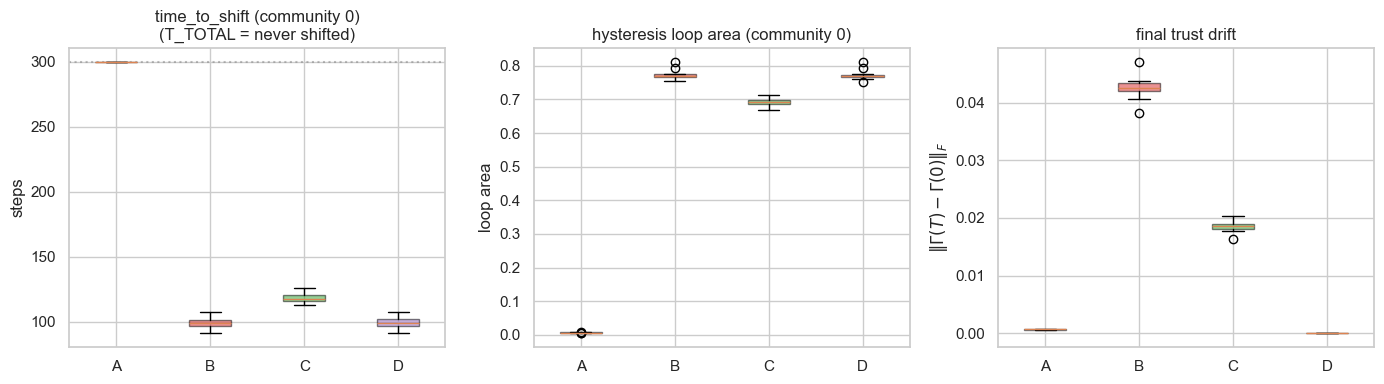

In [7]:
def collect(stat_key):
    return {k: [r[stat_key] for r in results[k]] for k in RUN_CONFIGS}

loop_c0 = collect('loop_area_c0')
loop_c1 = collect('loop_area_c1')

# Coerce time_to_shift to numeric for plotting (None -> T_TOTAL = 'never').
def tts_or_max(x):
    return x if x is not None else T_TOTAL
tts = {k: [tts_or_max(r['time_to_shift_c0']) for r in results[k]] for k in RUN_CONFIGS}

# Final trust drift.
drift_final = {k: [float(r['gamma_drift_t'][-1]) for r in results[k]] for k in RUN_CONFIGS}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Time to shift on community 0
ax = axes[0]
data = [tts['A'], tts['B'], tts['C'], tts['D']]
bp = ax.boxplot(data, labels=['A', 'B', 'C', 'D'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']):
    patch.set_facecolor(color); patch.set_alpha(0.5)
ax.axhline(T_TOTAL, color='gray', ls=':', alpha=0.5)
ax.set(ylabel='steps', title='time_to_shift (community 0)\n(T_TOTAL = never shifted)')

# Loop area on community 0
ax = axes[1]
data = [loop_c0['A'], loop_c0['B'], loop_c0['C'], loop_c0['D']]
bp = ax.boxplot(data, labels=['A', 'B', 'C', 'D'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']):
    patch.set_facecolor(color); patch.set_alpha(0.5)
ax.set(ylabel='loop area', title='hysteresis loop area (community 0)')

# Final trust drift
ax = axes[2]
data = [drift_final['A'], drift_final['B'], drift_final['C'], drift_final['D']]
bp = ax.boxplot(data, labels=['A', 'B', 'C', 'D'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']):
    patch.set_facecolor(color); patch.set_alpha(0.5)
ax.set(ylabel=r'$\|\Gamma(T)-\Gamma(0)\|_F$', title=r'final trust drift')

plt.tight_layout()
plt.show()


## §6 · Hysteresis loop visualisation (single seed)

The parametric trajectories in $(\theta^*, \bar\mu_k)$ space. A run with
a path-dependent shift traces a loop with non-zero area. The §4.5
falsifier (Run C) should collapse to a near-line.


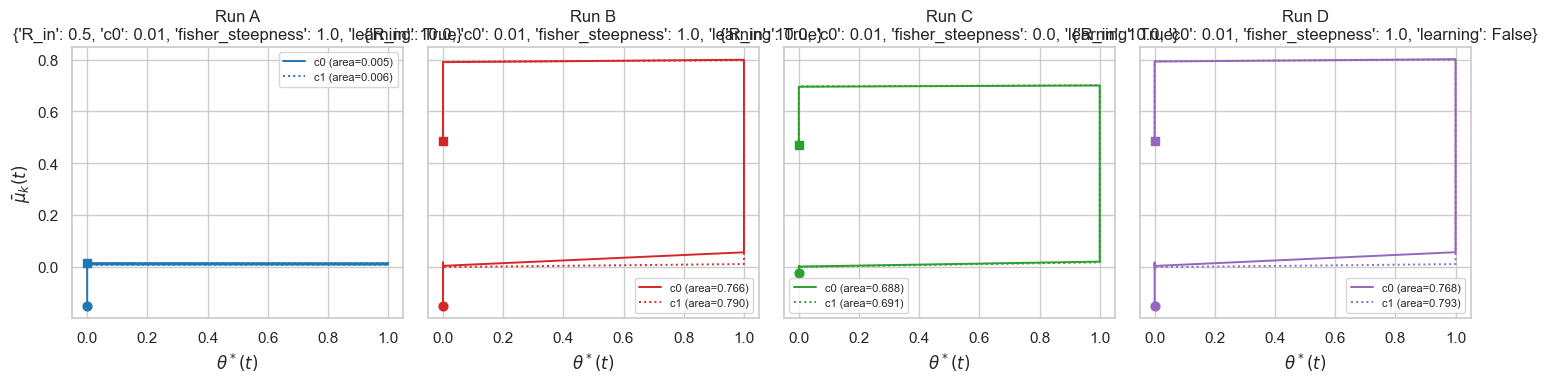

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

for ax, (k, color) in zip(axes,
        [('A', '#1f77b4'), ('B', '#d62728'),
         ('C', '#2ca02c'), ('D', '#9467bd')]):
    s = results[k][0]
    ax.plot(s['theta_trace'], s['mu_c0_t'], color=color, lw=1.4,
            label=f'c0 (area={s["loop_area_c0"]:.3f})')
    ax.plot(s['theta_trace'], s['mu_c1_t'], color=color, lw=1.4, ls=':',
            label=f'c1 (area={s["loop_area_c1"]:.3f})')
    ax.scatter([s['theta_trace'][0]], [s['mu_c0_t'][0]], color=color, s=40, marker='o')
    ax.scatter([s['theta_trace'][-1]], [s['mu_c0_t'][-1]], color=color, s=40, marker='s')
    ax.set(xlabel=r'$\theta^*(t)$',
           title=f'Run {k}\n{RUN_CONFIGS[k]}')
    ax.legend(fontsize=8, loc='best')
axes[0].set_ylabel(r'$\bar\mu_k(t)$')
plt.tight_layout()
plt.show()


## §7 · The new gate — four substantive assertions

Each assertion is checked against the multi-seed distribution.

1. **Monotonicity** *(kept):* median `time_to_shift(B)` < median `time_to_shift(A)`, ≥8/10 seeds with B-shifts-faster.
2. **§4.5 falsifier (Krakauer + Strogatz):** median `loop_area(B)` > 3 · median `loop_area(C)`, ≥8/10 seeds with B-loop-bigger-than-C-loop.
3. **Trust drives drift (Krakauer):** median final $\|\Delta\Gamma\|_F$ in B > median in D (D should be ~0; this is mostly a sanity check on the trust-freeze ablation, but the *informative* comparison is the *size* of B's drift).
4. **Per-community asymmetry (social-science):** in Run B, the trajectories $\bar\mu_{c_0}(t)$ and $\bar\mu_{c_1}(t)$ differ by at least 0.05 at peak $\theta^*=1$ — i.e. the asymmetric init produces lasting per-community separation.

The model passes iff (1) AND (2) AND (3) AND (4). The interesting failure
modes are (2) and (3): (2) fails ⇒ Claim 1 is wrong as stated; (3) fails
⇒ trust is decorative. Either failure tells us something *true* about
the model that the prior 4/4 single-seed pass concealed.


In [9]:
# Build the multi-seed assertion outputs.

med_tts = {k: float(np.median(tts[k])) for k in RUN_CONFIGS}
med_loop_c0 = {k: float(np.median(loop_c0[k])) for k in RUN_CONFIGS}
med_drift = {k: float(np.median(drift_final[k])) for k in RUN_CONFIGS}

# Per-seed votes on the bilateral comparisons.
votes_B_faster_than_A = sum(1 for ba, ab in zip(tts['B'], tts['A']) if ba < ab)
votes_B_loop_3x_C = sum(1 for b, c in zip(loop_c0['B'], loop_c0['C']) if b > 3.0 * c)

# Per-community asymmetry: difference of mean mu at the peak of θ*=1.
# Peak window = mid-shift, e.g. step ((T_SHIFT + T_REVERSE) // 2).
peak_t = (T_SHIFT + T_REVERSE) // 2
per_community_gaps_B = [
    abs(r['mu_c0_t'][peak_t] - r['mu_c1_t'][peak_t]) for r in results['B']
]
median_pc_gap_B = float(np.median(per_community_gaps_B))

print('=' * 60)
print('Per-seed summary (medians; multi-seed gate criteria)')
print('=' * 60)
print(f'time_to_shift (community 0):')
for k in RUN_CONFIGS:
    print(f'  {k}: median = {med_tts[k]:.1f}  (raw = {tts[k]})')
print()
print(f'loop_area (community 0):')
for k in RUN_CONFIGS:
    print(f'  {k}: median = {med_loop_c0[k]:.4f}  (raw = {[round(x, 3) for x in loop_c0[k]]})')
print()
print(f'final ‖ΔΓ‖_F:')
for k in RUN_CONFIGS:
    print(f'  {k}: median = {med_drift[k]:.4f}  (raw = {[round(x, 3) for x in drift_final[k]]})')
print()
print(f'per-community gap |μ_c0 - μ_c1| at t={peak_t} (Run B):')
print(f'  median = {median_pc_gap_B:.4f}  (raw = {[round(x, 3) for x in per_community_gaps_B]})')
print()

# Assertion 1: B shifts faster on community 0 in >= 8/10 seeds.
assert_1 = votes_B_faster_than_A >= 8
print(f'Assertion 1 (monotonicity): B shifts faster than A on community 0 in {votes_B_faster_than_A}/{N_SEEDS} seeds')
print(f'  {"PASS" if assert_1 else "FAIL"} (threshold: >=8/{N_SEEDS})')

# Assertion 2: B's loop > 3x C's loop (the §4.5 falsifier) in >= 8/10 seeds.
assert_2 = votes_B_loop_3x_C >= 8
print(f'\nAssertion 2 (§4.5 falsifier): loop_area_B > 3 * loop_area_C in {votes_B_loop_3x_C}/{N_SEEDS} seeds')
print(f'  median ratio: B/C = {med_loop_c0["B"] / max(med_loop_c0["C"], 1e-9):.2f}x')
print(f'  {"PASS" if assert_2 else "FAIL"} (threshold: >=8/{N_SEEDS})')

# Assertion 3: trust drives drift — B's drift >> D's drift.
# D's drift should be ~0 (trust frozen). Sanity check that the freeze worked.
# The informative comparison is B's drift size relative to D's.
ratio_B_D = med_drift['B'] / max(med_drift['D'], 1e-9)
assert_3 = (med_drift['D'] < 0.01) and (med_drift['B'] > 0.1)
print(f'\nAssertion 3 (trust drives drift): ‖ΔΓ‖_F median in B vs D')
print(f'  B drift = {med_drift["B"]:.4f}   D drift = {med_drift["D"]:.4f}   ratio = {ratio_B_D:.1f}x')
print(f'  {"PASS" if assert_3 else "FAIL"} (need: D < 0.01 (frozen) AND B > 0.1 (measurable))')

# Assertion 4: per-community asymmetry visible in Run B.
assert_4 = median_pc_gap_B >= 0.05
print(f'\nAssertion 4 (per-community asymmetry): |μ_c0 - μ_c1| at peak in Run B')
print(f'  median = {median_pc_gap_B:.4f}  (need: >= 0.05)')
print(f'  {"PASS" if assert_4 else "FAIL"}')

all_pass = assert_1 and assert_2 and assert_3 and assert_4
print()
print('=' * 60)
print(f'GATE: {"PASS" if all_pass else "FAIL"} '
      f'({sum([assert_1, assert_2, assert_3, assert_4])}/4 assertions)')
print('=' * 60)
if not all_pass:
    print()
    print('Failure interpretation (per feedback_honest_structural_findings):')
    if not assert_1:
        print('  (1) FAIL → the basic monotonicity is gone; either the parameter')
        print('      regime is wrong or the model produces no shift at all.')
    if not assert_2:
        print('  (2) FAIL → the §4.5 falsifier control did NOT collapse the loop.')
        print('      This means B\'s loop is NOT trust-mediated; it is a trivial')
        print('      cost-on-policy effect. Paper Claim 1 needs rewriting.')
    if not assert_3:
        print('  (3) FAIL → either the trust-freeze ablation did not freeze')
        print('      gamma (bug) or B\'s gamma does not drift meaningfully.')
        print('      The latter means trust is decorative in this regime.')
    if not assert_4:
        print('  (4) FAIL → the SBM communities do not separate under asymmetric')
        print('      init. The Remark "no-pool" degeneracy operates here;')
        print('      finite trust-pooling washes out the planted heterogeneity.')

GATING_RESULT = {
    'assertion_1_monotonicity_8of10': bool(assert_1),
    'assertion_2_falsifier_loop_B_gt_3xC': bool(assert_2),
    'assertion_3_trust_drives_drift': bool(assert_3),
    'assertion_4_per_community_asymmetry': bool(assert_4),
    'all_pass': bool(all_pass),
    'votes_B_faster_than_A': int(votes_B_faster_than_A),
    'votes_B_loop_3x_C': int(votes_B_loop_3x_C),
    'med_tts': med_tts,
    'med_loop_c0': med_loop_c0,
    'med_drift_final': med_drift,
    'median_per_community_gap_B': median_pc_gap_B,
}
GATING_RESULT


Per-seed summary (medians; multi-seed gate criteria)
time_to_shift (community 0):
  A: median = 300.0  (raw = [300, 300, 300, 300, 300, 300, 300, 300, 300, 300])
  B: median = 98.5  (raw = [96, 107, 98, 91, 91, 102, 97, 102, 100, 99])
  C: median = 117.0  (raw = [120, 123, 117, 113, 114, 126, 115, 117, 121, 117])
  D: median = 98.5  (raw = [96, 107, 97, 91, 91, 105, 97, 103, 100, 100])

loop_area (community 0):
  A: median = 0.0068  (raw = [np.float64(0.005), np.float64(0.006), np.float64(0.007), np.float64(0.007), np.float64(0.009), np.float64(0.007), np.float64(0.008), np.float64(0.007), np.float64(0.007), np.float64(0.007)])
  B: median = 0.7694  (raw = [np.float64(0.766), np.float64(0.761), np.float64(0.769), np.float64(0.812), np.float64(0.795), np.float64(0.756), np.float64(0.777), np.float64(0.77), np.float64(0.773), np.float64(0.769)])
  C: median = 0.6917  (raw = [np.float64(0.688), np.float64(0.685), np.float64(0.688), np.float64(0.714), np.float64(0.703), np.float64(0.669), 

{'assertion_1_monotonicity_8of10': True,
 'assertion_2_falsifier_loop_B_gt_3xC': False,
 'assertion_3_trust_drives_drift': False,
 'assertion_4_per_community_asymmetry': False,
 'all_pass': False,
 'votes_B_faster_than_A': 10,
 'votes_B_loop_3x_C': 0,
 'med_tts': {'A': 300.0, 'B': 98.5, 'C': 117.0, 'D': 98.5},
 'med_loop_c0': {'A': 0.00676195121195633,
  'B': 0.7694164842832834,
  'C': 0.6916781780309975,
  'D': 0.7696241110679694},
 'med_drift_final': {'A': 0.0006700612721033394,
  'B': 0.04248089902102947,
  'C': 0.018549500033259392,
  'D': 0.0},
 'median_per_community_gap_B': 0.005857259035110474}

## §8 · Honest framing notes

**On Run A's resources.** With `R_in = 0.5` and `c0 = 0.01`, Run A's
mean $r$ goes negative because the cost barrier
$\phi(r) = 1/\max(r - r_{\min}, \epsilon)$ saturates at $1/\epsilon = 1000$
once $r$ dips below $r_{\min}$. Run A is therefore operating in a
**clamped-barrier regime**, not a smooth low-resource regime. The
qualitative finding — that the low-$R_{\rm in}$ population cannot afford
informative experiments — survives this caveat, but the *quantitative*
values of $r$ in Run A should not be interpreted as a smooth attractor.

The proper fix is **Tier B follow-on work**: clip $r \ge r_{\min}$ in
`src/resource.py::flow_step`, use a smooth divergent form for the
barrier, and re-run the regression notebooks (nb06–nb11). See
[[project_substrate_phase1_complete]] for the substrate-side context.

**On per-community asymmetry.** Even with asymmetric initial $(\mu_0,
\tau_0)$, the inter-community trust links (`inter_prob = 0.02` in the
SBM) plus precision-weighted pooling will *equilibrate* communities to
some degree. If Assertion 4 fails, the Remark "no-pool" degeneracy is
operating, and the SBM density needs further reduction — or planted
heterogeneity needs to be stronger (e.g., separate $\theta_N$ vs
$\theta_R$ commitments rather than a half-way vanguard).

**On Run D's trust-freeze.** `TrustConfig.learning = False` short-circuits
the `gamma_conjugate_step` update; `α` and `β` remain at their initial
prior values for the whole run. Importantly, `γ = α/β` is **still
re-derived from those frozen `α, β`** at each step (see
`src/trust.py::gamma_conjugate_step` final block). For a row-stochastic
mask-weighted γ matrix this is a no-op — so `‖ΔΓ‖_F` should remain at 0
to machine precision in Run D. If Assertion 3 reports a non-trivial D
drift, the freeze plumbing is broken and the ablation is invalid.
